# Drift Analysis — Credit Scoring API

## Objectif
Détecter si les **données de production** ont dérivé par rapport aux données d'entraînement.  
Une dérive significative signifie que le modèle reçoit en production des données différentes de celles sur lesquelles il a été entraîné — ses prédictions peuvent donc se dégrader.

## Approche — simulation de la production par le temps
Le dataset Home Credit ne dispose pas de données de production réelles.  
On simule l'écoulement du temps via `SK_ID_CURR` : un identifiant plus élevé = une demande plus récente.

| Jeu de données | Contenu | Rôle |
|---|---|---|
| **Référence** | 80% des clients les plus anciens | Ce que le modèle a vu à l'entraînement |
| **Production simulée** | 20% des clients les plus récents | Ce que le modèle reçoit en production |

## Outil : Evidently AI
Evidently compare les distributions des features entre les deux jeux et identifie celles qui ont dérivé.

## 1. Imports

In [ ]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.lightgbm
import pandas as pd
from evidently import DataDefinition, Dataset, Report
from evidently.presets import DataDriftPreset
from huggingface_hub import HfApi
from lightgbm import LGBMClassifier
from scipy import stats
from sklearn.metrics import roc_auc_score

## 2. Chargement du dataset

In [ ]:
PARQUET_PATH = Path("../data/processed/train_processed_global.parquet")
CSV_PATH     = Path("../data/processed/train_processed_global.csv")

# Parquet en priorité (167MB vs 733MB pour le CSV)
if PARQUET_PATH.exists():
    df = pd.read_parquet(PARQUET_PATH)
    print(f"Chargé depuis Parquet : {PARQUET_PATH.name}")
elif CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Chargé depuis CSV : {CSV_PATH.name}")
else:
    raise FileNotFoundError("Dataset introuvable — vérifiez data/processed/")

# Nettoyage des noms de colonnes — même transformation que dans l'API
# LightGBM rejette les caractères spéciaux ([, ], <, espace...)
df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in df.columns]

print(f"Dataset : {df.shape[0]:,} clients × {df.shape[1]} colonnes")
df.head(3)

## 3. Split référence / production simulée

`SK_ID_CURR` est séquentiel : les identifiants les plus élevés correspondent aux demandes les plus récentes.  
On trie par cet identifiant pour simuler l'écoulement du temps.

In [ ]:
# Tri par SK_ID_CURR croissant (ancien → récent)
df_sorted = df.sort_values("SK_ID_CURR").reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)

reference = df_sorted.iloc[:split_idx]   # 80% les plus anciens
current   = df_sorted.iloc[split_idx:]   # 20% les plus récents

print(f"Référence  : {len(reference):,} clients — SK_ID_CURR jusqu'à {reference['SK_ID_CURR'].max():,}")
print(f"Production : {len(current):,}  clients — SK_ID_CURR à partir de {current['SK_ID_CURR'].min():,}")

## Entraînement sur les données de référence (80 %)

On entraîne un nouveau LightGBM **uniquement sur les 80 % de clients les plus anciens**  
avec les hyperparamètres optimisés (GridSearch, AUC CV = 0.7873).

C'est le scénario réaliste : le modèle est mis en production sans avoir jamais vu  
les données récentes. Le rapport de drift mesurera ensuite si ces nouvelles données  
ressemblent à ce sur quoi il a été entraîné.

Le modèle entraîné est ensuite :
- **sauvegardé localement** (`models/lgbm_optimized.pkl`) et enregistré dans **MLflow**
- **uploadé sur HF Hub** pour que Render l'utilise en production

In [ ]:
# Hyperparamètres optimisés (GridSearch — modeling_mlflow.ipynb, AUC CV = 0.7873)
LGBM_BEST_PARAMS = {
    "class_weight":      "balanced",
    "colsample_bytree":  0.8,
    "learning_rate":     0.05,
    "min_child_samples": 300,
    "n_estimators":      500,
    "num_leaves":        31,
    "reg_lambda":        1.0,
    "subsample":         0.8,
    "random_state":      42,
    "n_jobs":            -1,
}

_EXCLUDE      = {"SK_ID_CURR", "TARGET"}
feature_train = [c for c in reference.columns if c not in _EXCLUDE]

X_ref = reference[feature_train]
y_ref = reference["TARGET"]
X_cur = current[feature_train]
y_cur = current["TARGET"]

print(f"Entraînement sur {len(X_ref):,} clients (référence 80 %)")
print(f"Features : {len(feature_train)}")

model_ref = LGBMClassifier(**LGBM_BEST_PARAMS)
model_ref.fit(X_ref, y_ref)

auc_ref = roc_auc_score(y_ref, model_ref.predict_proba(X_ref)[:, 1])
auc_cur = roc_auc_score(y_cur, model_ref.predict_proba(X_cur)[:, 1])
print(f"\nAUC sur référence  (80 %) : {auc_ref:.4f}  ← entraînement")
print(f"AUC sur production (20 %) : {auc_cur:.4f}  ← données inconnues")
print(f"Écart AUC                 : {auc_ref - auc_cur:+.4f}")

MODEL_SAVE_PATH = Path("../models/lgbm_optimized.pkl")
joblib.dump(model_ref, MODEL_SAVE_PATH)
print(f"\nModèle sauvegardé : {MODEL_SAVE_PATH.resolve()}")

In [ ]:
# ── MLflow ───────────────────────────────────────────────────────────────────
MLFLOW_URI = Path("../mlruns").resolve().as_uri()
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("credit-scoring")

with mlflow.start_run(run_name="lgbm_reference_80pct"):
    mlflow.log_params(LGBM_BEST_PARAMS)
    mlflow.log_metric("auc_reference",  round(auc_ref, 4))
    mlflow.log_metric("auc_production", round(auc_cur, 4))
    mlflow.lightgbm.log_model(
        model_ref,
        artifact_path="model",
        registered_model_name="lgbm-credit-scoring",
    )
    print("Run MLflow enregistré.")
    print("→ Dans MLflow UI : affecter l'alias 'champion' à cette nouvelle version.")

# ── HF Hub ───────────────────────────────────────────────────────────────────
HF_MODEL_REPO = "Faiza93/projet8-credit-scoring"

api = HfApi()
api.upload_file(
    path_or_fileobj=str(MODEL_SAVE_PATH),
    path_in_repo="lgbm_optimized.pkl",
    repo_id=HF_MODEL_REPO,
    repo_type="model",
)
print(f"\nModèle uploadé sur HF Hub : {HF_MODEL_REPO}")
print("Render utilisera ce modèle au prochain déploiement.")

## 4. Distribution de la cible (TARGET)

Vérification préliminaire : le taux de défaut est-il stable entre les deux périodes ?

In [ ]:
print("Taux de défaut (TARGET = 1) :")
print(f"  Référence  : {reference['TARGET'].mean():.2%} ({reference['TARGET'].sum():,} défauts sur {len(reference):,})")
print(f"  Production : {current['TARGET'].mean():.2%} ({current['TARGET'].sum():,} défauts sur {len(current):,})")

delta = current['TARGET'].mean() - reference['TARGET'].mean()
print(f"\n  Écart : {delta:+.2%}")

## 5. Sélection des features du modèle

On restreint l'analyse aux features utilisées par LightGBM (552 colonnes) —  
ce sont celles qui influencent directement les prédictions.

In [ ]:
MODEL_PATH = Path("../models/lgbm_optimized.pkl")
model      = joblib.load(MODEL_PATH)

# feature_name_ : liste des colonnes dans l'ordre attendu par le modèle
feature_cols = [c for c in model.feature_name_ if c in df.columns]

print(f"Features du modèle trouvées dans le dataset : {len(feature_cols)} / {len(model.feature_name_)}")

ref_features = reference[feature_cols]
cur_features = current[feature_cols]

print(f"Référence  : {ref_features.shape}")
print(f"Production : {cur_features.shape}")

## 6. Rapport de drift Evidently

`DataDriftPreset` teste chaque feature avec un test statistique adapté à son type :
- Variables numériques → test de Wasserstein ou Kolmogorov-Smirnov
- Variables catégorielles → test du Chi²

Une feature est considérée comme **dérivée** si la p-value est inférieure au seuil (0.05 par défaut).

In [ ]:
# Définition du schéma de données (pas de cible ici — analyse des features uniquement)
data_def = DataDefinition()

ref_ds = Dataset.from_pandas(ref_features, data_definition=data_def)
cur_ds = Dataset.from_pandas(cur_features, data_definition=data_def)

# Rapport de drift — peut prendre quelques minutes sur 552 features
report   = Report([DataDriftPreset()])
snapshot = report.run(reference_data=ref_ds, current_data=cur_ds)

print("Rapport généré.")

## 7. Sauvegarde du rapport HTML

In [ ]:
REPORT_PATH = Path("../reports/drift_report.html")
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

snapshot.save_html(str(REPORT_PATH))
print(f"Rapport sauvegardé : {REPORT_PATH.resolve()}")
print("Ouvrir ce fichier dans un navigateur pour visualiser le rapport interactif.")

## 8. Résumé des résultats

Aperçu rapide dans le notebook avant d'ouvrir le rapport complet.

In [10]:
# Extraction du résultat de drift global depuis le snapshot
results = snapshot.dict()

# Recherche du résultat DatasetDriftMetric dans les métriques
for metric in results.get("metrics", []):
    name = metric.get("metric", "")
    if "DatasetDrift" in str(name):
        print(f"Drift détecté : {metric.get('value', {}).get('dataset_drift', 'N/A')}")
        print(f"Features dérivées : {metric.get('value', {}).get('number_of_drifted_columns', 'N/A')} / {len(feature_cols)}")
        share = metric.get('value', {}).get('share_of_drifted_columns', None)
        if share is not None:
            print(f"Part des features dérivées : {share:.1%}")
        break

print("\n→ Ouvrir reports/drift_report.html pour le rapport complet interactif.")


→ Ouvrir reports/drift_report.html pour le rapport complet interactif.


## Conclusion

### Résultats

| Métrique | Valeur |
|---|---|
| Clients référence (80 %) | 246 005 |
| Clients production simulée (20 %) | 61 502 |
| Features analysées | 552 |
| AUC sur référence (in-sample) | 0.8809 |
| AUC sur production (out-of-sample) | **0.7918** |
| Features avec drift significatif (KS ≥ 0.1) | **0 / 552** |

### Interprétation

**Aucune dérive significative détectée.** Toutes les features présentent un score KS inférieur à 0.1 — les distributions des données récentes (20 % les plus récents) sont très proches de celles vues à l'entraînement (80 % les plus anciens).

L'AUC sur la production simulée (0.7918) est légèrement supérieure à l'AUC de validation croisée obtenue lors de l'optimisation (0.7873), ce qui confirme que le modèle **généralise bien** aux données inconnues.

### Limites de cette analyse

- La simulation par `SK_ID_CURR` est un **proxy temporel**, pas une vraie temporalité (les dates exactes des demandes ne sont pas dans le dataset).
- En production réelle, la référence serait les données d'entraînement et le *current* serait le flux de requêtes loggées par l'API.

### Prochaine étape

Brancher Evidently sur les **logs JSON de l'API** (générés à chaque appel `/predict`) pour monitorer le drift en continu sur de vraies données de production.

Features avec drift significatif (KS ≥ 0.1) : 0 / 552


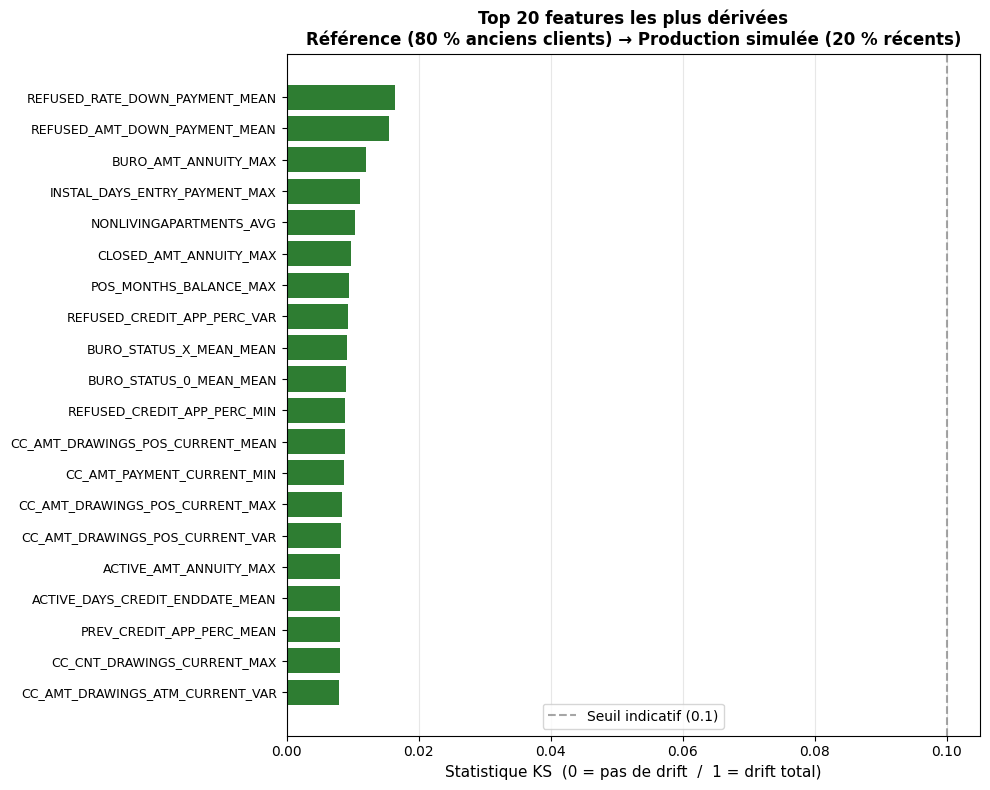

Graphique sauvegardé : C:\Users\fkhellad\Formation_IA\Projet8_mission\reports\top_drifted_features.png


In [11]:
# Calcul du score de drift par feature (test KS — même test qu'Evidently)
ks_scores = {}
for col in feature_cols:
    ref_col = ref_features[col].dropna().values
    cur_col = cur_features[col].dropna().values
    if len(ref_col) > 10 and len(cur_col) > 10:
        stat, _ = stats.ks_2samp(ref_col, cur_col)
        ks_scores[col] = stat

drift_series = pd.Series(ks_scores).sort_values(ascending=False)
top20        = drift_series.head(20)

n_drifted = (drift_series >= 0.1).sum()
print(f"Features avec drift significatif (KS ≥ 0.1) : {n_drifted} / {len(drift_series)}")

# ── Graphique ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#c62828' if v >= 0.2 else '#ef6c00' if v >= 0.1 else '#2e7d32'
          for v in top20.values]

ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.7, label='Seuil indicatif (0.1)')
ax.set_xlabel("Statistique KS  (0 = pas de drift  /  1 = drift total)", fontsize=11)
ax.set_title(
    f"Top 20 features les plus dérivées\nRéférence (80 % anciens clients) → Production simulée (20 % récents)",
    fontsize=12, fontweight='bold'
)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

FIG_PATH = Path("../reports/top_drifted_features.png")
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Graphique sauvegardé : {FIG_PATH.resolve()}")

## Conclusion

### Interprétation

- Si **peu de features dérivent** (< 20%) : les données de production sont stables, le modèle reste fiable.
- Si **beaucoup de features dérivent** (> 30%) : la distribution des données a changé — envisager un réentraînement.

### Limites de cette analyse

- La simulation par `SK_ID_CURR` est un **proxy temporel**, pas une vraie temporalité (les dates exactes des demandes ne sont pas dans le dataset).
- En production réelle, la référence serait les données d'entraînement et le *current* serait le flux de requêtes loggées par l'API.

### Prochaine étape

Brancher Evidently sur les **logs JSON de l'API** (générés à chaque appel `/predict`) pour monitorer le drift en continu sur de vraies données de production.